# Import data set, initial EDA and first pass cleaning

In [289]:
#import beach water sample csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/Lfab33/Python_Class/aef2bde8106b7d0ce321061b89704ab39a5fccb6/CSV/beachwatersamples.csv'
df = pd.read_csv(url)

df.head()

,Sample ID,Sample Date,Beach Name,Sample Location,Enterococci Results,Units or Notes
0,JB2609141040-1.1,09/14/2026,SCHUYLER HILL CIVIC ASSOCIATION,Left,10.0,MPN/100 ml
1,KB2609140940-1.1,09/14/2026,SEA GATE BEACH CLUB,Left,9.9,MPN/100 ml
2,JB2609141005-1.2,09/14/2026,WEST FORDHAM STREET ASSOCIATION,Center,31.0,MPN/100 ml
3,KB2609140940-1.3,09/14/2026,SEA GATE BEACH CLUB,Right,20.0,MPN/100 ml
4,JB2609141005-1.3,09/14/2026,WEST FORDHAM STREET ASSOCIATION,Right,10.0,MPN/100 ml


**Explore** the data set and see what data is available to work with


In [290]:
#How many rows and columns of data
df.shape

(31170, 6)

In [291]:
#what does our index look like
df.index


RangeIndex(start=0, stop=31170, step=1)

In [292]:
#what are the columns
df.columns

Index(['Sample ID', 'Sample Date', 'Beach Name', 'Sample Location',
       'Enterococci Results', 'Units or Notes'],
      dtype='object')

In [293]:
#what is the data type of each column
print (df.dtypes)

Sample ID               object
Sample Date             object
Beach Name              object
Sample Location         object
Enterococci Results    float64
Units or Notes          object
dtype: object


In [294]:
#convert the Sample Date to a useable datetime format; check that it worked

df['Sample Date'] = pd.to_datetime(df['Sample Date'])
df['Sample Date'].head()

,Sample Date
0,2026-09-14
1,2026-09-14
2,2026-09-14
3,2026-09-14
4,2026-09-14


In [295]:
#subset the df to see if conversion worked
subset=df [["Beach Name", "Sample Date"]]
subset.head()

,Beach Name,Sample Date
0,SCHUYLER HILL CIVIC ASSOCIATION,2026-09-14
1,SEA GATE BEACH CLUB,2026-09-14
2,WEST FORDHAM STREET ASSOCIATION,2026-09-14
3,SEA GATE BEACH CLUB,2026-09-14
4,WEST FORDHAM STREET ASSOCIATION,2026-09-14


In [296]:
#how many unique beach locations have samples
df['Beach Name'].nunique()

48

In [297]:
#what are the beach names
print (df['Beach Name'].unique())

['SCHUYLER HILL CIVIC ASSOCIATION' 'SEA GATE BEACH CLUB'
 'WEST FORDHAM STREET ASSOCIATION' 'DOUGLASTON HOMEOWNERS ASSOCIATION'
 'ORCHARD BEACH' 'WHITESTONE BOOSTER CIVIC  ASSOCIATION' 'DANISH AMERICAN'
 'MORRIS YACHT AND BEACH CLUB' 'CONEY ISLAND WEST 16TH - WEST 27TH'
 'SOUTH BEACH' 'CONEY ISLAND BR. 15TH - 6TH' 'MIDLAND BEACH'
 'MANHATTAN BEACH' 'CONEY ISLAND BR. 6TH - OCEAN PKWY'
 'CONEY ISLAND OCEAN PKWY - WEST 8TH' 'CONEY ISLAND WEST 8TH - PIER'
 'CONEY ISLAND WEST 28TH - WEST 37TH' 'ROCKAWAY BEACH 126TH - 149TH'
 'ROCKAWAY BEACH 116TH - 126TH' 'ROCKAWAY BEACH 95TH - 116TH'
 'ROCKAWAY BEACH 15TH - 22ND' 'BREEZY POINT - REID AVE.'
 'ROCKAWAY BEACH 9TH - 13TH' 'ROCKAWAY BEACH 59TH - 80TH'
 'ROCKAWAY BEACH 80TH - 95TH' 'BREEZY POINT - 219TH STREET.'
 'ROCKAWAY BEACH 23RD - 59TH' 'WHITE CROSS FISHING CLUB' 'TRINITY DANISH'
 'AMERICAN TURNERS' '658 SUNRISE CLUB INC.' "WOLFE'S POND BEACH"
 'KINGSBOROUGH COMMUNITY COLLEGE' 'SEA GATE 42ND' 'GERRITSEN/KIDDIE BEACH'
 'CEDAR GROVE' 'DANISH 

In [298]:
#what is the date range of our data set?

min_date = df['Sample Date'].min()
max_date = df['Sample Date'].max()

print("Earliest Date:", min_date)
print("Latest Date:", max_date)


Earliest Date: 2005-05-02 00:00:00
Latest Date: 2026-09-14 00:00:00


In [299]:
#it would be useful to have a column with just the year for analysis, add a column and populate it with the year.
df['Year']= df['Sample Date'].dt.year


In [300]:
#how many water samples do we have for each beach per year
df.groupby(['Beach Name', 'Year'])['Sample ID'].count()


Beach Name             Year
658 SUNRISE CLUB INC.  2026    60
AMERICAN TURNERS       2005    63
                       2006    71
                       2007    63
                       2008    60
                               ..
WOLFE'S POND PARK      2021    36
                       2022    75
                       2023    60
                       2024    60
                       2025    63
Name: Sample ID, Length: 809, dtype: int64

In [301]:
#what years were each beach tested
with pd.option_context('display.max_colwidth', None):
  print (df.groupby('Beach Name') ['Year'].unique())


Beach Name
658 SUNRISE CLUB INC.                                                                                                                                                   [2026]
AMERICAN TURNERS                          [2026, 2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005]
BEECHHURST PROPERTY OWNERS ASSOCIATION                                                                                                                                  [2013]
BREEZY POINT - 219TH STREET                     [2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005]
BREEZY POINT - 219TH STREET.                                                                                                                                            [2026]
BREEZY POINT - REID AVE.                  [2026, 2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015,

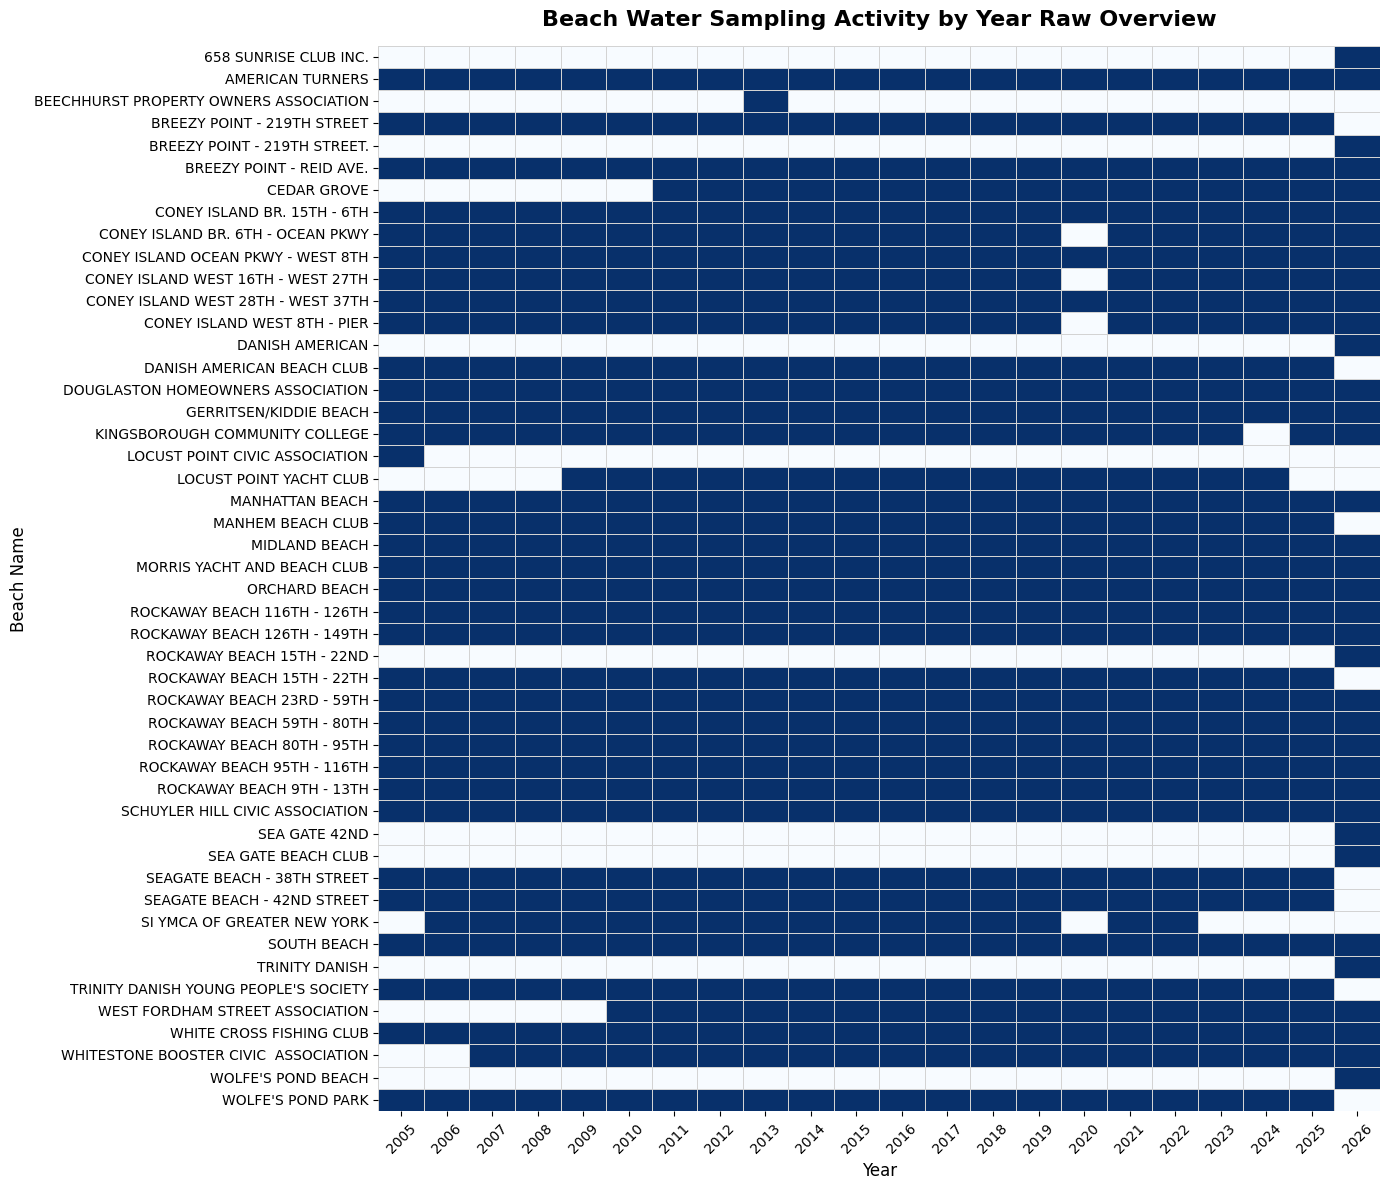

In [302]:
#Explore the data visually to get a quick overview

# 1. Create a binary pivot table (1 if a beach has data for that year, 0 if it doesn't)
presence_matrix = pd.crosstab(df['Beach Name'], df['Year']).clip(upper=1)

# 2. Set up the figure size (wide enough for the years, tall enough for all beach names)
plt.figure(figsize=(14, 12))

# 3. Create the heatmap
sns.heatmap(
    presence_matrix,
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor="lightgray"
)

# 4. Label and style the chart
plt.title("Beach Water Sampling Activity by Year Raw Overview", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Beach Name", fontsize=12)
plt.xticks(rotation=45) # Angle the years so they don't overlap

# 5. Display the plot
plt.tight_layout()
plt.show()


In [303]:
#what is in the white boxes, check, is it empty rows? - yes it's empty, so
#no need to worry about it throwing off the mean or median

df [
(df['Beach Name']=='CONEY ISLAND BR. 6TH - OCEAN PKWY')&
(df['Year']==2020)
]

,Sample ID,Sample Date,Beach Name,Sample Location,Enterococci Results,Units or Notes,Year


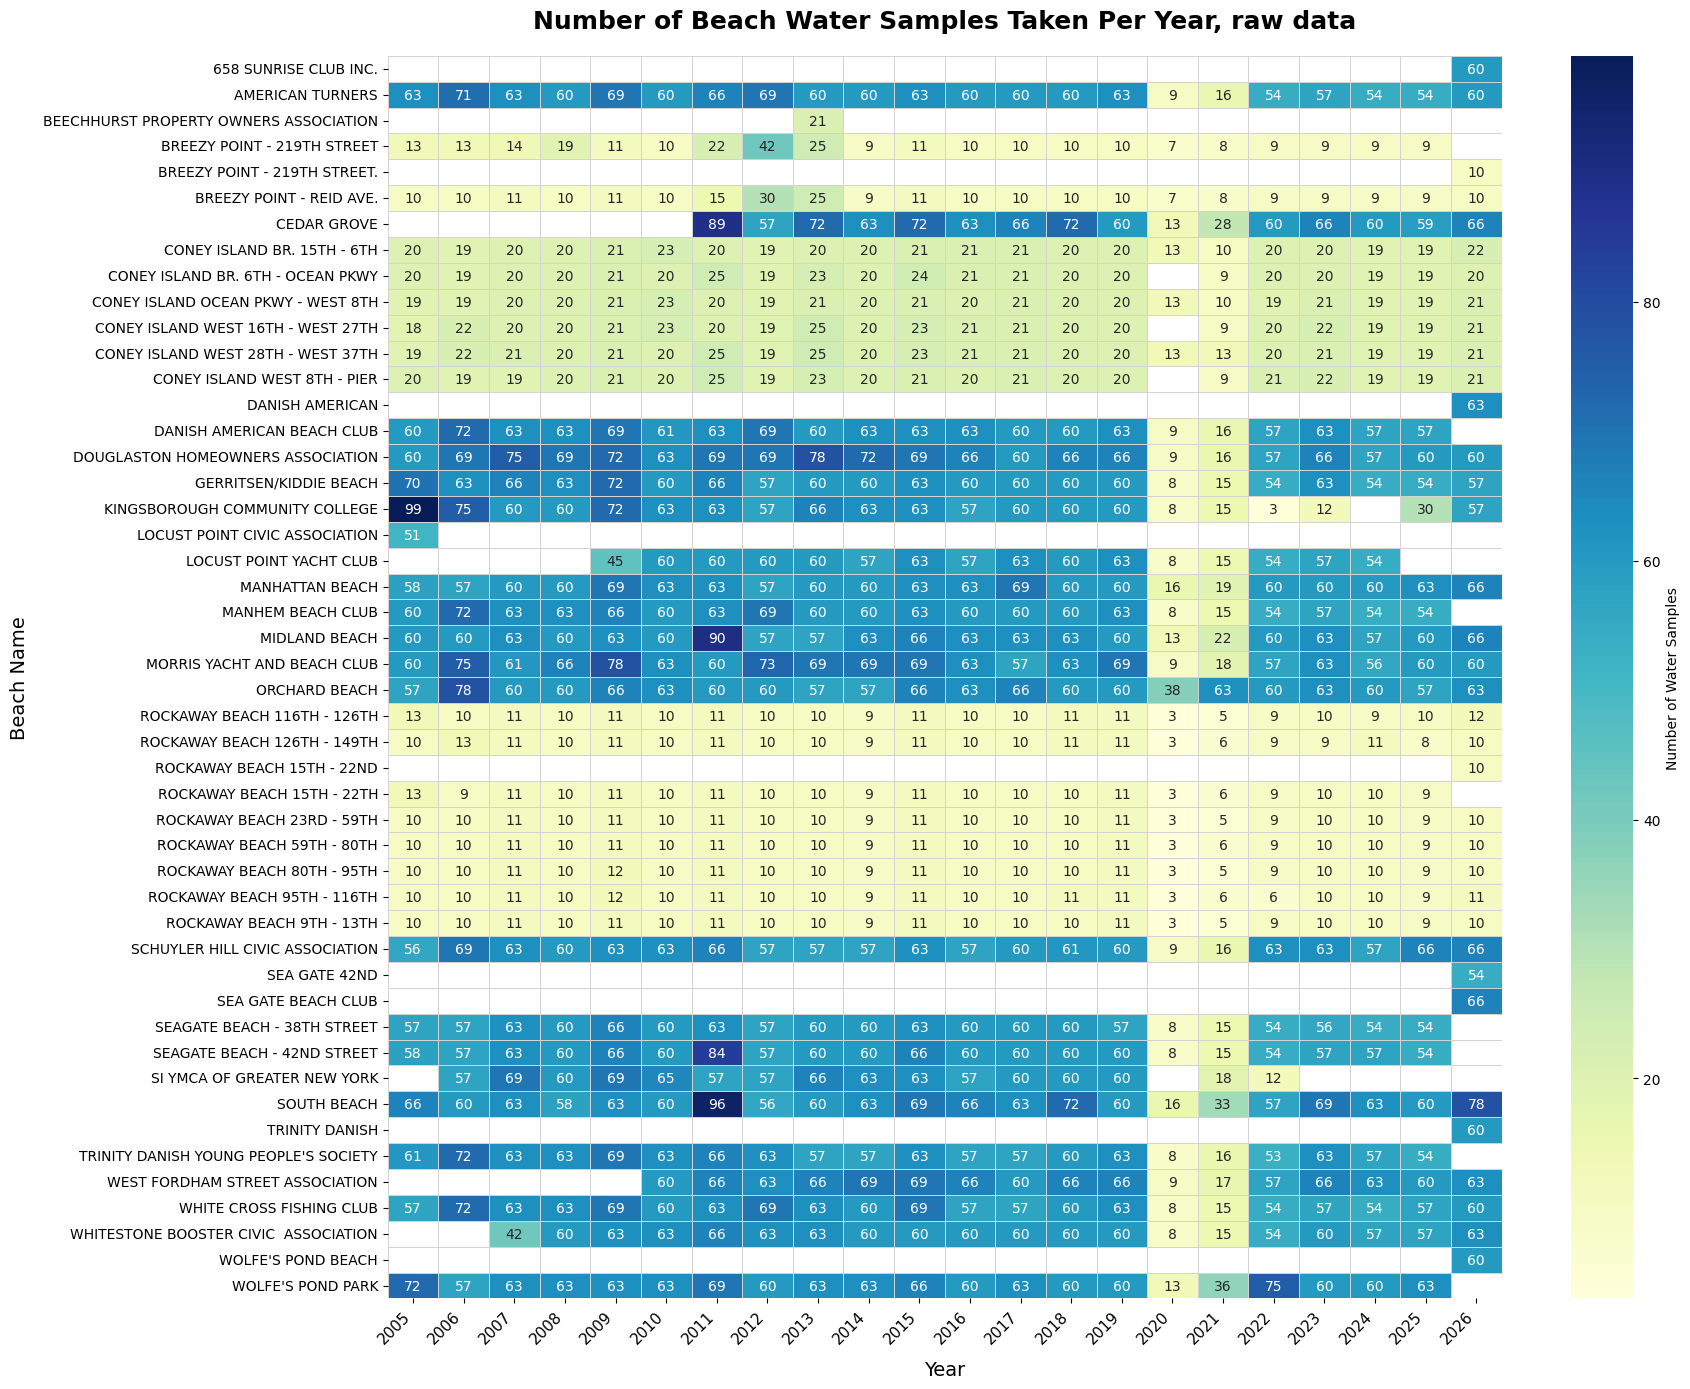

In [304]:
#Create another heatmap to see number of samples displayed as well, to gain a better understanding

presence_matrix = df.groupby(['Beach Name', 'Year']).size().unstack(fill_value=0)

# 2. Set up a large figure size so the text inside the boxes remains readable
plt.figure(figsize=(18, 14))

# 3. Create a mask so we don't crowd the chart writing "0" in empty boxes
mask = (presence_matrix == 0)

# 4. Generate the heatmap with annotations
sns.heatmap(
    presence_matrix,
    annot=True,
    fmt="g",
    cmap="YlGnBu",
    mask=mask,
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={'label': 'Number of Water Samples'}
)

# 5. Add titles and adjust labels
plt.title("Number of Beach Water Samples Taken Per Year, raw data", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Year", fontsize=14, labelpad=10)
plt.ylabel("Beach Name", fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=10)

# 6. Adjust layout so nothing cuts off
plt.tight_layout()
plt.show()


# Test for nulls, and explore possible imputation methods


In [305]:
#are there any null values?
df.isnull().values.any()



np.True_

In [306]:
#how many nulls and where are they?
df.isnull().sum()


,0
Sample ID,0
Sample Date,0
Beach Name,0
Sample Location,37
Enterococci Results,7464
Units or Notes,0
Year,0


**7464** results is a lot of NaNs relative to our data set. Let's explore what that's about, and see if we can find out what the NaNs mean.

Some possibilities:

*   are the NaNs entered if no test was performed?
*   are the NaNs entered if the test malfunctioned or was faulty somehow?

*   Some other reason?
*   Should we drop the NaNs (ie so that potentially incomplete tests don't skew the data?)






In [307]:
#Filter the dataframe to only look at missing enterococci results
missing_data = df[df['Enterococci Results'].isnull()]


missing_summary = missing_data.groupby(['Beach Name', 'Year']).size().reset_index(name='Missing Samples Count')

# UNCOMMENT IF YOU WANT TO SEE ALL ROWS:
# with pd.option_context('display.max_rows', None):

print(missing_summary)


                Beach Name  Year  Missing Samples Count
0    658 SUNRISE CLUB INC.  2026                      3
1         AMERICAN TURNERS  2005                     17
2         AMERICAN TURNERS  2006                     17
3         AMERICAN TURNERS  2007                     24
4         AMERICAN TURNERS  2008                     16
..                     ...   ...                    ...
589      WOLFE'S POND PARK  2016                     30
590      WOLFE'S POND PARK  2017                     28
591      WOLFE'S POND PARK  2018                     30
592      WOLFE'S POND PARK  2019                     30
593      WOLFE'S POND PARK  2020                      4

[594 rows x 3 columns]


In [308]:
#Test one beach and see if it tells us something about what the NaN values are

#UNCOMMENT TO SEE ALL ROWS
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)

df[(df['Beach Name'] == "658 SUNRISE CLUB INC.") &
   (df['Year'] == 2026)]

#I see NaNs here, but no explanation about what it means

,Sample ID,Sample Date,Beach Name,Sample Location,Enterococci Results,Units or Notes,Year
84,KB2609011000-1.3,2026-09-01,658 SUNRISE CLUB INC.,Right,10.0,MPN/100 ml,2026
87,KB2609011000-1.2,2026-09-01,658 SUNRISE CLUB INC.,Center,10.0,MPN/100 ml,2026
91,KB2609011000-1.1,2026-09-01,658 SUNRISE CLUB INC.,Left,10.0,MPN/100 ml,2026
132,KB2608250910-1.1,2026-08-25,658 SUNRISE CLUB INC.,Left,9.9,MPN/100 ml,2026
141,KB2608250910-1.3,2026-08-25,658 SUNRISE CLUB INC.,Right,9.9,MPN/100 ml,2026
156,KB2608250910-1.2,2026-08-25,658 SUNRISE CLUB INC.,Center,9.9,MPN/100 ml,2026
222,KB2608180950-1.2,2026-08-18,658 SUNRISE CLUB INC.,Center,63.0,MPN/100 ml,2026
230,KB2608180950-1.1,2026-08-18,658 SUNRISE CLUB INC.,Left,41.0,MPN/100 ml,2026
238,KB2608180950-1.3,2026-08-18,658 SUNRISE CLUB INC.,Right,41.0,MPN/100 ml,2026
293,KB2608110955-1.1,2026-08-11,658 SUNRISE CLUB INC.,Left,20.0,MPN/100 ml,2026


In [309]:
#Let's try another beach:

df[(df['Beach Name'] == 'AMERICAN TURNERS') &
   (df['Year'] == 2007)]

#This beach shows us that the NaN values represent that the sample tested below the detection limit

,Sample ID,Sample Date,Beach Name,Sample Location,Enterococci Results,Units or Notes,Year
27008,090507BH15,2007-09-05,AMERICAN TURNERS,Right,NaN,Result below detection limit,2007
27013,090507BH14,2007-09-05,AMERICAN TURNERS,Center,NaN,Result below detection limit,2007
27018,090507BH13,2007-09-05,AMERICAN TURNERS,Left,8.0,MPN/100 ml,2007
27110,082707BH14,2007-08-27,AMERICAN TURNERS,Center,16.0,MPN/100 ml,2007
27121,082707BH13,2007-08-27,AMERICAN TURNERS,Left,16.0,MPN/100 ml,2007
...,...,...,...,...,...,...,...
28285,050107IM14,2007-05-01,AMERICAN TURNERS,Center,NaN,Result below detection limit,2007
28286,050107IM15,2007-05-01,AMERICAN TURNERS,Right,NaN,Result below detection limit,2007
28342,042407IM13,2007-04-24,AMERICAN TURNERS,Left,4.0,MPN/100 ml,2007
28358,042407IM15,2007-04-24,AMERICAN TURNERS,Right,NaN,Result below detection limit,2007


In [310]:
#Let's look at another example to verify

df[(df['Beach Name'] == "TRINITY DANISH YOUNG PEOPLE'S SOCIETY") &
   (df['Year'] == 2007)]

#Yes, this shows us the same result.

,Sample ID,Sample Date,Beach Name,Sample Location,Enterococci Results,Units or Notes,Year
27009,090507BH21,2007-09-05,TRINITY DANISH YOUNG PEOPLE'S SOCIETY,Right,NaN,Result below detection limit,2007
27010,090507BH20,2007-09-05,TRINITY DANISH YOUNG PEOPLE'S SOCIETY,Center,8.0,MPN/100 ml,2007
27019,090507BH19,2007-09-05,TRINITY DANISH YOUNG PEOPLE'S SOCIETY,Left,NaN,Result below detection limit,2007
27111,082707BH21,2007-08-27,TRINITY DANISH YOUNG PEOPLE'S SOCIETY,Right,NaN,Result below detection limit,2007
27118,082707BH20,2007-08-27,TRINITY DANISH YOUNG PEOPLE'S SOCIETY,Center,4.0,MPN/100 ml,2007
...,...,...,...,...,...,...,...
28283,050107IM08,2007-05-01,TRINITY DANISH YOUNG PEOPLE'S SOCIETY,Center,NaN,Result below detection limit,2007
28295,050107IM07,2007-05-01,TRINITY DANISH YOUNG PEOPLE'S SOCIETY,Left,NaN,Result below detection limit,2007
28352,042407IM08,2007-04-24,TRINITY DANISH YOUNG PEOPLE'S SOCIETY,Center,NaN,Result below detection limit,2007
28353,042407IM07,2007-04-24,TRINITY DANISH YOUNG PEOPLE'S SOCIETY,Left,NaN,Result below detection limit,2007


In [311]:
#Let's count number of instances of Results Below Detection Limit. It should approximate the number of NaNs
(df['Units or Notes'].str.strip() == 'Result below detection limit').sum()




np.int64(7445)

7445 is 19 fewer NaNs than 7464, so I am comfortable with interpreting all of the NaNs as indicating 'Result below detection limit' Let's keep the NaNs, as this actually indicates a clean water sample. Omitting them would give a false impression of higher incidence of bacteria being found. Unsure if I should impute the NaN with 0 or 0.5, will try both ways.

**Imputation methodology and testing:** Comparing 0 with 0.5 imputation in two data frames and analyze the results. According to the EPA, 0.5 MPN/100mL (half the detection limit) is the recommended value to impute. Imputing 0 will underestimate bacterial presence and prevent log-transformations

In [312]:
#Impute 0 for NaNs in results
df_zero = df.copy()
df_zero['Enterococci Results'] = df_zero['Enterococci Results'].fillna(0)

original_nan = df['Enterococci Results'].isna()
df_zero.loc[original_nan, ['Beach Name', 'Year', 'Enterococci Results']]




,Beach Name,Year,Enterococci Results
427,DANISH AMERICAN,2026,0.0
590,658 SUNRISE CLUB INC.,2026,0.0
591,DANISH AMERICAN,2026,0.0
592,SCHUYLER HILL CIVIC ASSOCIATION,2026,0.0
596,AMERICAN TURNERS,2026,0.0
...,...,...,...
30955,WOLFE'S POND PARK,2005,0.0
30960,SEAGATE BEACH - 42ND STREET,2005,0.0
30961,SEAGATE BEACH - 38TH STREET,2005,0.0
30963,SEAGATE BEACH - 42ND STREET,2005,0.0


In [313]:
#descriptive stats for the whole data set, imputing 0 for NaNs
df_zero['Enterococci Results'].describe()

,Enterococci Results
count,31170.000000
mean,69.973282
std,452.771884
min,0.000000
25%,4.000000
50%,9.900000
75%,24.000000
max,24196.000000


In [314]:
#Impute 0.5 for NaNs in results
df_pt5 = df.copy()
df_pt5['Enterococci Results'] = df_pt5['Enterococci Results'].fillna(0.5)

original_nan = df['Enterococci Results'].isna()
df_pt5.loc[original_nan, ['Beach Name', 'Year', 'Enterococci Results']]

,Beach Name,Year,Enterococci Results
427,DANISH AMERICAN,2026,0.5
590,658 SUNRISE CLUB INC.,2026,0.5
591,DANISH AMERICAN,2026,0.5
592,SCHUYLER HILL CIVIC ASSOCIATION,2026,0.5
596,AMERICAN TURNERS,2026,0.5
...,...,...,...
30955,WOLFE'S POND PARK,2005,0.5
30960,SEAGATE BEACH - 42ND STREET,2005,0.5
30961,SEAGATE BEACH - 38TH STREET,2005,0.5
30963,SEAGATE BEACH - 42ND STREET,2005,0.5


In [315]:
#descriptive stats for whole data set, using 0.5 as imputation
df_pt5['Enterococci Results'].describe()

,Enterococci Results
count,31170.000000
mean,70.093013
std,452.753430
min,0.500000
25%,4.000000
50%,9.900000
75%,24.000000
max,24196.000000


In [316]:
#descriptive stats for each year, zero imputation
df_zero.groupby('Year')['Enterococci Results'].describe()


,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2005,1350.0,39.296815,214.114775,0.0,4.0,9.9,24.0,6400.0
2006,1418.0,41.534556,190.472871,0.0,0.0,8.0,28.0,4000.0
2007,1419.0,64.025370,435.008116,0.0,0.0,4.0,16.0,8000.0
2008,1400.0,19.743571,81.213830,0.0,0.0,4.0,12.0,1400.0
2009,1570.0,58.312102,222.505650,0.0,0.0,4.0,24.0,4800.0
2010,1522.0,54.218791,297.817757,0.0,0.0,8.0,24.0,8800.0
2011,1768.0,74.977941,427.252553,0.0,0.0,8.0,28.0,12000.0
2012,1622.0,65.312577,388.578836,0.0,4.0,8.0,32.0,11000.0
2013,1662.0,70.372984,544.544131,0.0,0.0,8.0,24.0,15000.0


In [317]:
#descriptive stats for each year, 0.5 imputation
df_pt5.groupby('Year')['Enterococci Results'].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2005,1350.0,39.402370,214.095485,0.5,4.000,9.9,24.0,6400.0
2006,1418.0,41.664669,190.444603,0.5,0.500,8.0,28.0,4000.0
2007,1419.0,64.199789,434.982492,0.5,0.500,4.0,16.0,8000.0
2008,1400.0,19.931071,81.168563,0.5,0.500,4.0,12.0,1400.0
2009,1570.0,58.461783,222.466512,0.5,0.500,4.0,24.0,4800.0
2010,1522.0,54.355782,297.792883,0.5,0.500,8.0,24.0,8800.0
2011,1768.0,75.116799,427.228229,0.5,0.500,8.0,28.0,12000.0
2012,1622.0,65.431258,388.558933,0.5,4.000,8.0,32.0,11000.0
2013,1662.0,70.523706,544.524689,0.5,0.500,8.0,24.0,15000.0


In [318]:
#better way to compare effects of imputation is sum, median and mean of bacteria counted, bc that is the
#number it's going to change. Count, min/max won't change. Make a new df with these values, then plot

pt5_sum = df_pt5['Enterococci Results'].sum()
zero_sum = df_zero['Enterococci Results'].sum()

pt5_mean = df_pt5['Enterococci Results'].mean()
zero_mean = df_zero['Enterococci Results'].mean()

pt5_median = df_pt5['Enterococci Results'].median()
zero_median = df_zero['Enterococci Results'].median()

# Create comparison DataFrame

comparison_df = pd.DataFrame({
    'Statistic': ['Sum', 'Mean', 'Median'],
    'point5 Imputation': [pt5_sum, pt5_mean, pt5_median],
    'Zero Imputation': [zero_sum, zero_mean, zero_median],
    'Difference (point5 - Zero)': [
        pt5_sum - zero_sum,
        pt5_mean - zero_mean,
        pt5_median - zero_median

    ]


})

comparison_df

,Statistic,point5 Imputation,Zero Imputation,Difference (point5 - Zero)
0,Sum,2.184799e+06,2.181067e+06,3732.000000
1,Mean,7.009301e+01,6.997328e+01,0.119731
2,Median,9.900000e+00,9.900000e+00,0.000000


In [319]:
#what does this look like over time

# Calculate yearly statistics

pt5_yearly = df_pt5.groupby('Year')['Enterococci Results'].agg(
    Sum='sum',
    Mean='mean',
    Median='median'
)

zero_yearly = df_zero.groupby('Year')['Enterococci Results'].agg(
    Sum='sum',
    Mean='mean',
    Median='median'
)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'point5 Sum': pt5_yearly['Sum'],
    'Zero Sum': zero_yearly['Sum'],
    'Sum Difference': pt5_yearly['Sum'] - zero_yearly['Sum'],

    'point5 Mean': pt5_yearly['Mean'],
    'Zero Mean': zero_yearly['Mean'],
    'Mean Difference': pt5_yearly['Mean'] - zero_yearly['Mean'],

    'point5 Median': pt5_yearly['Median'],
    'Zero Median': zero_yearly['Median']
})

# Keep years 2005–2026
comparison_df = comparison_df.loc[2005:2026]

# Make Year a column
comparison_df = comparison_df.reset_index()

comparison_df



,Year,point5 Sum,Zero Sum,Sum Difference,point5 Mean,Zero Mean,Mean Difference,point5 Median,Zero Median
0,2005,53193.2,53050.7,142.5,39.402370,39.296815,0.105556,9.9,9.9
1,2006,59080.5,58896.0,184.5,41.664669,41.534556,0.130113,8.0,8.0
2,2007,91099.5,90852.0,247.5,64.199789,64.025370,0.174419,4.0,4.0
3,2008,27903.5,27641.0,262.5,19.931071,19.743571,0.187500,4.0,4.0
4,2009,91785.0,91550.0,235.0,58.461783,58.312102,0.149682,4.0,4.0
5,2010,82729.5,82521.0,208.5,54.355782,54.218791,0.136991,8.0,8.0
6,2011,132806.5,132561.0,245.5,75.116799,74.977941,0.138857,8.0,8.0
7,2012,106129.5,105937.0,192.5,65.431258,65.312577,0.118681,8.0,8.0
8,2013,117210.4,116959.9,250.5,70.523706,70.372984,0.150722,8.0,8.0
9,2014,89408.0,89084.0,324.0,56.984066,56.777565,0.206501,4.0,4.0


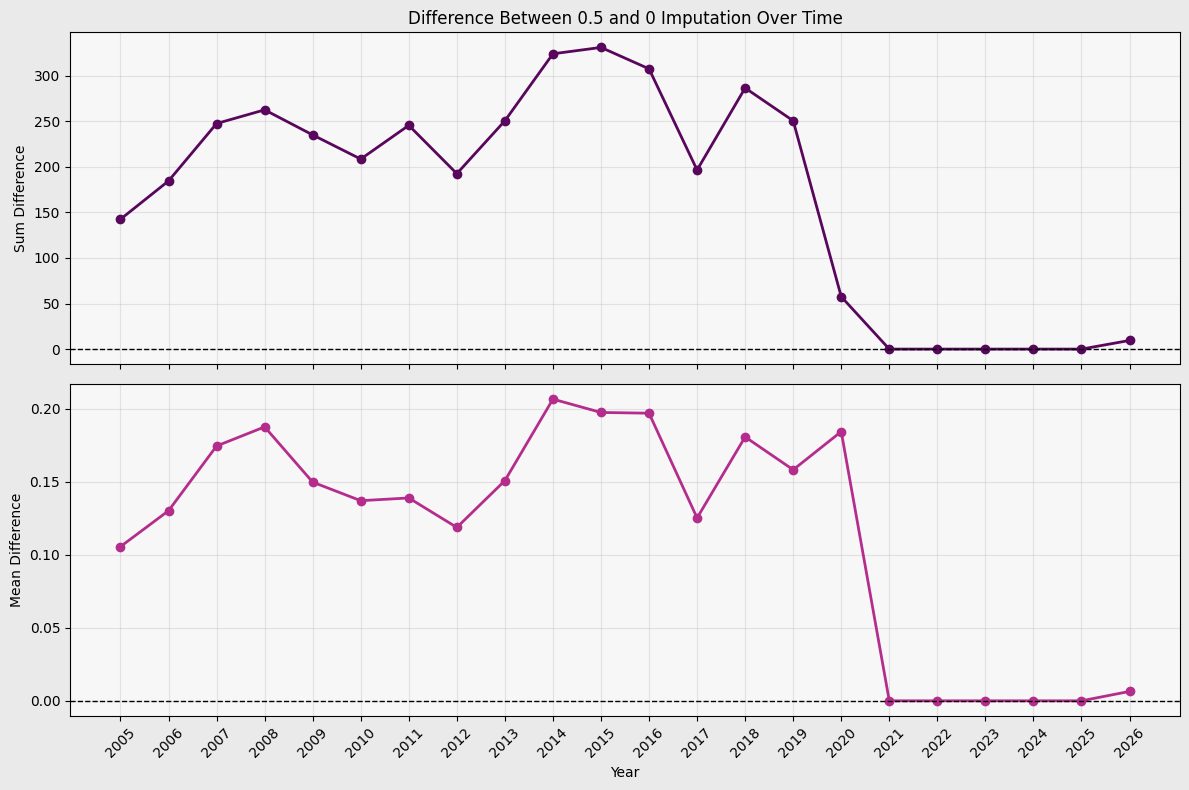

In [320]:
#plot the difference between imputation methods for both  sum and mean.
#since median remains constant to 6 dec places, don't need to plot

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True
)

# Main figure background
fig.patch.set_facecolor('#EAEAEA')

# Individual plot backgrounds
ax1.set_facecolor('#F7F7F7')
ax2.set_facecolor('#F7F7F7')

# Sum difference
ax1.plot(
    comparison_df['Year'],
    comparison_df['Sum Difference'],
    marker='o',
    color='#58075c',
    linewidth=2
)

ax1.axhline(0, color='black', linestyle='--', linewidth=1)
ax1.set_ylabel('Sum Difference')
ax1.set_title('Difference Between 0.5 and 0 Imputation Over Time')
ax1.grid(alpha=0.3)

# Mean difference
ax2.plot(
    comparison_df['Year'],
    comparison_df['Mean Difference'],
    marker='o',
    color='#b52d8c',
    linewidth=2
)

ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Year')
ax2.set_ylabel('Mean Difference')
ax2.grid(alpha=0.3)

plt.xticks(comparison_df['Year'], rotation=45)

plt.tight_layout()
plt.show()


# Create new data frame and second pass cleaning

In [321]:
# Create a clean copy of the original DataFrame.

df_clean = df.copy()

#strip whitespace from beach names, just in case

df_clean['Beach Name'] = (
    df_clean['Beach Name']
    .astype('string')
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

#drop beaches with incomplete data (these four had many years of incomplete data)

drop_beaches = [
    'BEECHHURST PROPERTY OWNERS ASSOCIATION',
    'LOCUST POINT CIVIC ASSOCIATION',
    'LOCUST POINT YACHT CLUB',
    'SI YMCA OF GREATER NEW YORK'
]

df_clean = df_clean[
    ~df_clean['Beach Name'].isin(drop_beaches)
].copy()


#merge duplicate beaches with slightly different names into one label

# Breezy Point 219th Street
mask = df_clean['Beach Name'].str.rstrip('.') == \
       'BREEZY POINT - 219TH STREET'

df_clean.loc[mask, 'Beach Name'] = 'BREEZY PT 219TH ST'


# Danish American / Danish American Beach Club
labels = [
    'DANISH AMERICAN',
    'DANISH AMERICAN BEACH CLUB'
]

df_clean.loc[
    df_clean['Beach Name'].isin(labels),
    'Beach Name'
] = 'DANISH AMERICAN BEACH CLUB'


# 658 Sunrise Club / Manhem Beach Club
labels = [
    '658 SUNRISE CLUB INC.',
    'MANHEM BEACH CLUB'
]

df_clean.loc[
    df_clean['Beach Name'].isin(labels),
    'Beach Name'
] = 'MANHEM BEACH CLUB'


# Rockaway Beach 15th / 22nd
labels = [
    'ROCKAWAY BEACH 15TH - 22TH',
    'ROCKAWAY BEACH 15TH - 22ND'
]

df_clean.loc[
    df_clean['Beach Name'].isin(labels),
    'Beach Name'
] = 'ROCKAWAY BEACH 15TH - 22ND'


# Seagate 42nd
labels = [
    'SEA GATE 42ND',
    'SEAGATE BEACH - 42ND STREET'
]

df_clean.loc[
    df_clean['Beach Name'].isin(labels),
    'Beach Name'
] = 'SEAGATE 42ND'


# Seagate 38th
labels = [
    'SEA GATE BEACH CLUB',
    'SEAGATE BEACH - 38TH STREET'
]

df_clean.loc[
    df_clean['Beach Name'].isin(labels),
    'Beach Name'
] = 'SEAGATE 38TH'


# Trinity Danish Young People's Society
labels = [
    'TRINITY DANISH',
    "TRINITY DANISH YOUNG PEOPLE'S SOCIETY"
]

df_clean.loc[
    df_clean['Beach Name'].isin(labels),
    'Beach Name'
] = 'TRINITY DANISH YOUNG PEOPLES SOCIETY'


# Wolfe's Pond Beach / Park
labels = [
    "WOLFE'S POND BEACH",
    "WOLFE'S POND PARK"
]

df_clean.loc[
    df_clean['Beach Name'].isin(labels),
    'Beach Name'
] = "WOLFES POND BEACH"

df_clean.head()

,Sample ID,Sample Date,Beach Name,Sample Location,Enterococci Results,Units or Notes,Year
0,JB2609141040-1.1,2026-09-14,SCHUYLER HILL CIVIC ASSOCIATION,Left,10.0,MPN/100 ml,2026
1,KB2609140940-1.1,2026-09-14,SEAGATE 38TH,Left,9.9,MPN/100 ml,2026
2,JB2609141005-1.2,2026-09-14,WEST FORDHAM STREET ASSOCIATION,Center,31.0,MPN/100 ml,2026
3,KB2609140940-1.3,2026-09-14,SEAGATE 38TH,Right,20.0,MPN/100 ml,2026
4,JB2609141005-1.3,2026-09-14,WEST FORDHAM STREET ASSOCIATION,Right,10.0,MPN/100 ml,2026


In [322]:
#after cleaning, how many rows of data
df_clean.shape

(29369, 7)

In [323]:
#after cleaning, how many unique beach locations have samples
df_clean['Beach Name'].nunique()

36

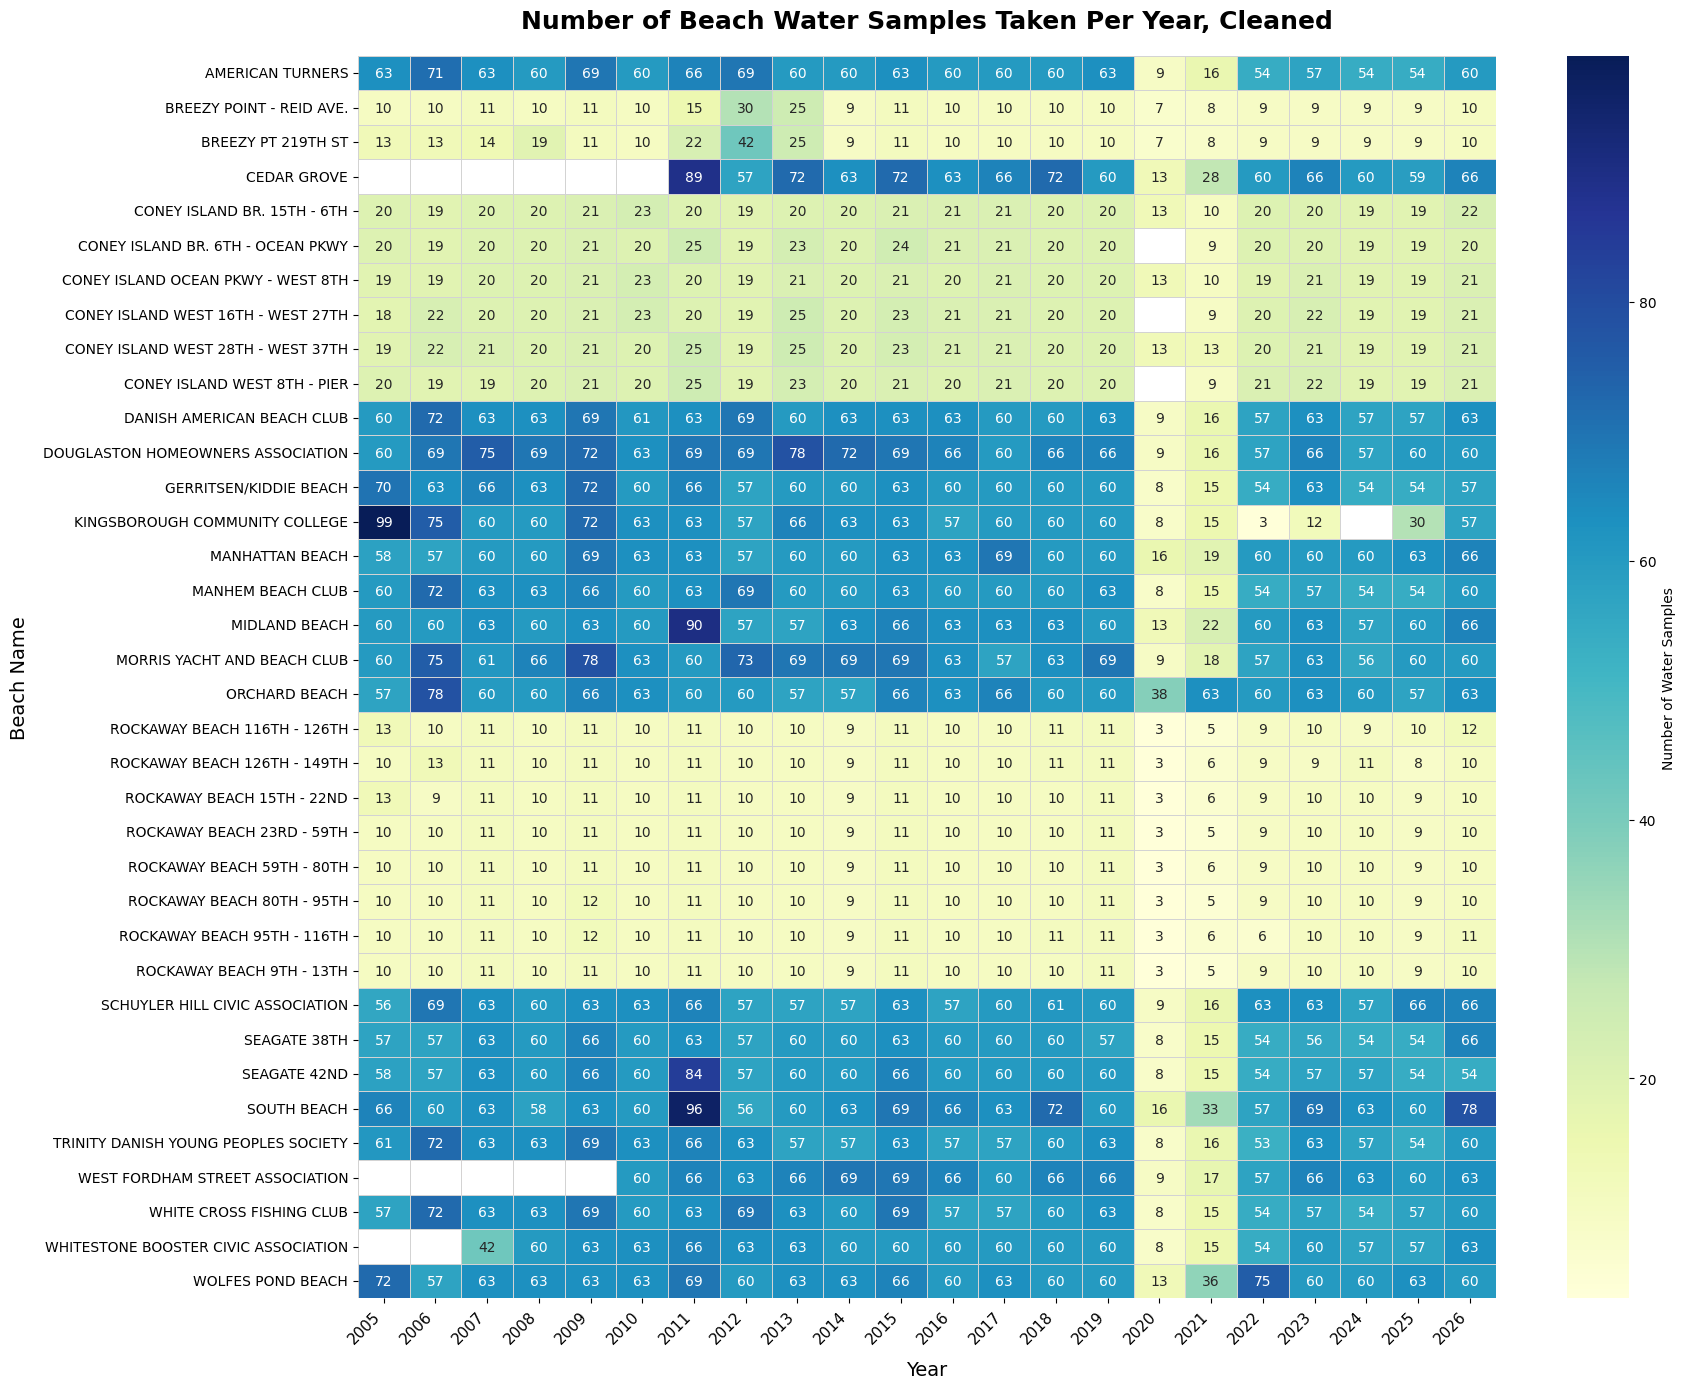

In [324]:
#Take a look at the cleaned data as a heatmap again to see if I missed anything

presence_matrix = df_clean.groupby(['Beach Name', 'Year']).size().unstack(fill_value=0)


plt.figure(figsize=(18, 14))


mask = (presence_matrix == 0)


sns.heatmap(
    presence_matrix,
    annot=True,
    fmt="g",
    cmap="YlGnBu",
    mask=mask,
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={'label': 'Number of Water Samples'}
)

plt.title("Number of Beach Water Samples Taken Per Year, Cleaned", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Year", fontsize=14, labelpad=10)
plt.ylabel("Beach Name", fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=10)


plt.tight_layout()
plt.show()

Now that we have figured out an imputation method and cleaned the data, let's think about how to analyze, what columns we want, and if we want to remove or add information.

Looking at the heatmap of number of samples taken, it's clear that not all beaches were sampled at the same rate.

Because the number of samples taken is different at each beach, we should normalize as a percentage when comparing beaches.

I think it makes the most sense to choose 2011-2026 as the analysis window.

2026 is a complete data set because NYC only tests from April-Sept, and publishes once a week while the beaches are open. NYC beaches closed on 9/13/26 this year, therefore the last publication date of 9/14/26 is the last one for the year.

Also, since there were between 1-3 tests per beach per day, we should express the samples in terms of observations, which would be and average of the samples for each beach per day. This will give us one value per observation.

It would be nice to have latitude/longitude data, borough, and whether the beach is public or private added to the df. I have created a csv with this information, adding to the data frame below.




# Merge geographical data and third cleaning pass

In [325]:
#create a new data frame that will have all of the information that we want for our analysis.
#Need to merge with geographical data csv that I created, which will populate Beach Name, Latitude, Longitude, Borough, Public_Private

# Load the separate dataset hosted on github
url = 'https://raw.githubusercontent.com/Lfab33/Python_Class/refs/heads/main/CSV/nyc_beaches_geo.csv'
df_geo = pd.read_csv(url)

df_geo.head()

#merge df_clean with geo data to make a new beach_df containing all of the cleaned data for our analysis

#Uncomment to check that the join will be clean without losing rows before you do it
# beach_check = pd.merge(
#     df_clean,
#     df_geo,
#     on='Beach Name',
#     how='outer',
#     indicator=True
# )
# beach_check['_merge'].value_counts()


beach_df = pd.merge(
    df_clean,
    df_geo,
    on='Beach Name',
    how='inner'
)

beach_df.head()

,Sample ID,Sample Date,Beach Name,Sample Location,Enterococci Results,Units or Notes,Year,Latitude,Longitude,Borough,Public_Private
0,JB2609141040-1.1,2026-09-14,SCHUYLER HILL CIVIC ASSOCIATION,Left,10.0,MPN/100 ml,2026,40.8174,-73.8123,Bronx,private
1,KB2609140940-1.1,2026-09-14,SEAGATE 38TH,Left,9.9,MPN/100 ml,2026,40.5750,-74.0080,Brooklyn,private
2,JB2609141005-1.2,2026-09-14,WEST FORDHAM STREET ASSOCIATION,Center,31.0,MPN/100 ml,2026,40.8475,-73.7845,Bronx,private
3,KB2609140940-1.3,2026-09-14,SEAGATE 38TH,Right,20.0,MPN/100 ml,2026,40.5750,-74.0080,Brooklyn,private
4,JB2609141005-1.3,2026-09-14,WEST FORDHAM STREET ASSOCIATION,Right,10.0,MPN/100 ml,2026,40.8475,-73.7845,Bronx,private


In [326]:
beach_df.shape

(29369, 11)

In [327]:
beach_df.columns


Index(['Sample ID', 'Sample Date', 'Beach Name', 'Sample Location',
       'Enterococci Results', 'Units or Notes', 'Year', 'Latitude',
       'Longitude', 'Borough', 'Public_Private'],
      dtype='object')

In [328]:
#Dont forget to impute 0.5 for NaNs in this new beach_df (forgot to do so in original df after testing)
beach_df['Enterococci Results'] = beach_df['Enterococci Results'].fillna(0.5)


In [329]:
#also impute 'Center' for 'Sample Location' and test that it worked
beach_df ['Sample Location'] = beach_df ['Sample Location'].fillna('Center')
print(beach_df['Sample Location'].isna().sum())

0


In [330]:
#and check that it worked
print(beach_df['Enterococci Results'].dtype)
print(beach_df['Enterococci Results'].isna().sum())



float64
0


In [331]:
#Now let's export our cleaned, revised beach_df to a csv and start a clean analysis

# Save DataFrame to a CSV file
beach_df.to_csv('beach_df.csv', index=False)

# Download the file to your computer
from google.colab import files
files.download('beach_df.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [332]:
beach_df.head()

,Sample ID,Sample Date,Beach Name,Sample Location,Enterococci Results,Units or Notes,Year,Latitude,Longitude,Borough,Public_Private
0,JB2609141040-1.1,2026-09-14,SCHUYLER HILL CIVIC ASSOCIATION,Left,10.0,MPN/100 ml,2026,40.8174,-73.8123,Bronx,private
1,KB2609140940-1.1,2026-09-14,SEAGATE 38TH,Left,9.9,MPN/100 ml,2026,40.5750,-74.0080,Brooklyn,private
2,JB2609141005-1.2,2026-09-14,WEST FORDHAM STREET ASSOCIATION,Center,31.0,MPN/100 ml,2026,40.8475,-73.7845,Bronx,private
3,KB2609140940-1.3,2026-09-14,SEAGATE 38TH,Right,20.0,MPN/100 ml,2026,40.5750,-74.0080,Brooklyn,private
4,JB2609141005-1.3,2026-09-14,WEST FORDHAM STREET ASSOCIATION,Right,10.0,MPN/100 ml,2026,40.8475,-73.7845,Bronx,private


# END CLEANING AND PREPARING DATA FRAME

# BEGIN ANALYSIS ON CLEANED DATA FRAME

In [333]:
#@title IMPORT CLEAN DATA FRAME as df, basic EDA and testing to confirm all is good
#import cleaned and prepped csv


url = 'https://raw.githubusercontent.com/Lfab33/Python_Class/refs/heads/main/CSV/beach_dfV3.csv'
df = pd.read_csv(url)

df.head()

,Sample ID,Sample Date,Beach Name,Sample Location,Enterococci Results,Units or Notes,Year,Latitude,Longitude,Borough,Public_Private
0,JB2609141040-1.1,2026-09-14,SCHUYLER HILL CIVIC ASSOCIATION,Left,10.0,MPN/100 ml,2026,40.8174,-73.8123,Bronx,private
1,KB2609140940-1.1,2026-09-14,SEAGATE 38TH,Left,9.9,MPN/100 ml,2026,40.5750,-74.0080,Brooklyn,private
2,JB2609141005-1.2,2026-09-14,WEST FORDHAM STREET ASSOCIATION,Center,31.0,MPN/100 ml,2026,40.8475,-73.7845,Bronx,private
3,KB2609140940-1.3,2026-09-14,SEAGATE 38TH,Right,20.0,MPN/100 ml,2026,40.5750,-74.0080,Brooklyn,private
4,JB2609141005-1.3,2026-09-14,WEST FORDHAM STREET ASSOCIATION,Right,10.0,MPN/100 ml,2026,40.8475,-73.7845,Bronx,private


In [334]:
#test with some basic EDA
df.shape

(29369, 11)

In [335]:
df.columns

Index(['Sample ID', 'Sample Date', 'Beach Name', 'Sample Location',
       'Enterococci Results', 'Units or Notes', 'Year', 'Latitude',
       'Longitude', 'Borough', 'Public_Private'],
      dtype='object')

In [336]:
df ['Beach Name'].nunique()

36

In [337]:
df ['Beach Name'].unique()

array(['SCHUYLER HILL CIVIC ASSOCIATION', 'SEAGATE 38TH',
       'WEST FORDHAM STREET ASSOCIATION',
       'DOUGLASTON HOMEOWNERS ASSOCIATION', 'ORCHARD BEACH',
       'WHITESTONE BOOSTER CIVIC ASSOCIATION',
       'DANISH AMERICAN BEACH CLUB', 'MORRIS YACHT AND BEACH CLUB',
       'CONEY ISLAND WEST 16TH - WEST 27TH', 'SOUTH BEACH',
       'CONEY ISLAND BR. 15TH - 6TH', 'MIDLAND BEACH', 'MANHATTAN BEACH',
       'CONEY ISLAND BR. 6TH - OCEAN PKWY',
       'CONEY ISLAND OCEAN PKWY - WEST 8TH',
       'CONEY ISLAND WEST 8TH - PIER',
       'CONEY ISLAND WEST 28TH - WEST 37TH',
       'ROCKAWAY BEACH 126TH - 149TH', 'ROCKAWAY BEACH 116TH - 126TH',
       'ROCKAWAY BEACH 95TH - 116TH', 'ROCKAWAY BEACH 15TH - 22ND',
       'BREEZY POINT - REID AVE.', 'ROCKAWAY BEACH 9TH - 13TH',
       'ROCKAWAY BEACH 59TH - 80TH', 'ROCKAWAY BEACH 80TH - 95TH',
       'BREEZY PT 219TH ST', 'ROCKAWAY BEACH 23RD - 59TH',
       'WHITE CROSS FISHING CLUB', 'TRINITY DANISH YOUNG PEOPLES SOCIETY',
       'AMERI

In [338]:
#what is the date range of our data set?

min_date = df['Sample Date'].min()
max_date = df['Sample Date'].max()

print("Earliest Date:", min_date)
print("Latest Date:", max_date)

Earliest Date: 2005-05-02
Latest Date: 2026-09-14


In [339]:
#double check that imputation worked.
df.isnull().sum()

,0
Sample ID,0
Sample Date,0
Beach Name,0
Sample Location,0
Enterococci Results,0
Units or Notes,0
Year,0
Latitude,0
Longitude,0
Borough,0


# Create df2 year filter 2011-2026

In [340]:
#let's create a new df using only the years with complete data, 2011-2026. From this point on,
#our analysis will use that date range for most complete data

df2 = df [ df['Year'].between(2011, 2026)
].copy()

df2.head()

,Sample ID,Sample Date,Beach Name,Sample Location,Enterococci Results,Units or Notes,Year,Latitude,Longitude,Borough,Public_Private
0,JB2609141040-1.1,2026-09-14,SCHUYLER HILL CIVIC ASSOCIATION,Left,10.0,MPN/100 ml,2026,40.8174,-73.8123,Bronx,private
1,KB2609140940-1.1,2026-09-14,SEAGATE 38TH,Left,9.9,MPN/100 ml,2026,40.5750,-74.0080,Brooklyn,private
2,JB2609141005-1.2,2026-09-14,WEST FORDHAM STREET ASSOCIATION,Center,31.0,MPN/100 ml,2026,40.8475,-73.7845,Bronx,private
3,KB2609140940-1.3,2026-09-14,SEAGATE 38TH,Right,20.0,MPN/100 ml,2026,40.5750,-74.0080,Brooklyn,private
4,JB2609141005-1.3,2026-09-14,WEST FORDHAM STREET ASSOCIATION,Right,10.0,MPN/100 ml,2026,40.8475,-73.7845,Bronx,private


# CREATE df3 TO COLLAPSE MULTIPLE SAMPLES INTO ONE OBSERVATION PER BEACH PER DAY AND BASIC EDA

In [341]:
# Create a new df that averages the sample locations, so we aren't over-counting amounts of bacteria and number of positive samples
df3 = (
    df2.groupby(
        ['Sample Date', 'Beach Name', 'Latitude', 'Longitude',
         'Borough', 'Year', 'Public_Private'],
        as_index=False
    )
    ['Enterococci Results']
    .mean()
    .rename(columns={'Enterococci Results': 'Ent SampleAvg'})
)

# Calculate observations and average Enterococci result by beach
beach_summary = (
    df3.groupby('Beach Name')
       .agg(
           Number_of_Observations=('Ent SampleAvg', 'count'),
           Average_Enterococci=('Ent SampleAvg', 'mean')
       )
       .reset_index()
)

# Re-order columns
df3 = df3[
    ['Sample Date', 'Beach Name', 'Ent SampleAvg',
     'Borough', 'Latitude', 'Longitude', 'Public_Private', 'Year']
]

df3.head()


,Sample Date,Beach Name,Ent SampleAvg,Borough,Latitude,Longitude,Public_Private,Year
0,2011-04-25,CEDAR GROVE,21.333333,Staten Island,40.5515,-74.1030,public,2011
1,2011-04-25,CONEY ISLAND BR. 15TH - 6TH,16.000000,Brooklyn,40.5745,-73.9575,public,2011
2,2011-04-25,CONEY ISLAND BR. 6TH - OCEAN PKWY,8.000000,Brooklyn,40.5740,-73.9680,public,2011
3,2011-04-25,CONEY ISLAND OCEAN PKWY - WEST 8TH,4.000000,Brooklyn,40.5732,-73.9740,public,2011
4,2011-04-25,CONEY ISLAND WEST 16TH - WEST 27TH,36.000000,Brooklyn,40.5715,-73.9875,public,2011


In [342]:
#check that the filter worked
min_date = df3['Sample Date'].min()
max_date = df3['Sample Date'].max()

print("Earliest Date:", min_date)
print("Latest Date:", max_date)

Earliest Date: 2011-04-25
Latest Date: 2026-09-14


In [343]:
#how many beaches are in each borough?
df3.groupby (['Borough', 'Public_Private'])['Beach Name'].nunique()

Borough        Public_Private
Bronx          private           8
               public            1
Brooklyn       private           4
               public            7
Queens         private           4
               public            8
Staten Island  public            4
Name: Beach Name, dtype: int64

In [344]:
#how many sample tests were conducted in each borough from 2011-2026
df2.groupby('Borough')['Sample ID'].count()

,Sample ID
Borough,
Bronx,8003
Brooklyn,5965
Queens,3397
Staten Island,3801


In [345]:
#how many observations do we have once samples are averaged?
df3.groupby('Borough')['Ent SampleAvg'].count()

,Ent SampleAvg
Borough,
Bronx,2802
Brooklyn,3265
Queens,2132
Staten Island,1352


# Descriptive stats of cleaned averaged data set

In [346]:
#what are the descriptive stats for all observations (averaged)
df3['Ent SampleAvg'].describe()

,Ent SampleAvg
count,9551.000000
mean,65.277837
std,416.059325
min,0.500000
25%,3.000000
50%,9.900000
75%,22.666667
max,24196.000000


In [347]:
#what are the descriptive stats for averaged tests meeting closure threshold
df3.loc[
    df3['Ent SampleAvg'] > 104,
    'Ent SampleAvg'
].describe()



,Ent SampleAvg
count,808.000000
mean,615.494142
std,1309.017596
min,104.333333
25%,150.500000
50%,243.666667
75%,560.000000
max,24196.000000


In [348]:
#what about above a much larger number of bacteria, looking for spikes if any
df3.loc[
    df3['Ent SampleAvg'] > 2500,
    'Ent SampleAvg'
].describe()

,Ent SampleAvg
count,31.000000
mean,5246.494624
std,4170.908571
min,2533.333333
25%,3389.166667
50%,3931.000000
75%,4836.000000
max,24196.000000


In [349]:
#explore spikes further, where are they, when, how many beaches involved?
spikes = (
    df3.loc[df3['Ent SampleAvg'] > 2500]
       .sort_values('Ent SampleAvg', ascending=False)
       .reset_index(drop=True)
)

spikes.head(40)


,Sample Date,Beach Name,Ent SampleAvg,Borough,Latitude,Longitude,Public_Private,Year
0,2025-06-17,TRINITY DANISH YOUNG PEOPLES SOCIETY,24196.000000,Bronx,40.8270,-73.8145,private,2025
1,2022-09-07,MORRIS YACHT AND BEACH CLUB,13622.000000,Bronx,40.8358,-73.7821,private,2022
2,2025-05-12,MIDLAND BEACH,8214.000000,Staten Island,40.5695,-74.0850,public,2025
3,2024-07-23,AMERICAN TURNERS,7731.666667,Bronx,40.8275,-73.8142,private,2024
4,2024-07-23,TRINITY DANISH YOUNG PEOPLES SOCIETY,7447.666667,Bronx,40.8270,-73.8145,private,2024
5,2011-05-17,DOUGLASTON HOMEOWNERS ASSOCIATION,7300.000000,Queens,40.7675,-73.7485,private,2011
6,2024-07-23,WHITE CROSS FISHING CLUB,5800.000000,Bronx,40.8252,-73.8155,private,2024
7,2012-07-31,ORCHARD BEACH,5038.666667,Bronx,40.8654,-73.7925,public,2012
8,2011-08-02,DOUGLASTON HOMEOWNERS ASSOCIATION,4633.333333,Queens,40.7675,-73.7485,private,2011
9,2025-07-15,DANISH AMERICAN BEACH CLUB,4570.000000,Bronx,40.8298,-73.8140,private,2025


In [350]:
#what beach/sample event showed the greatest bacteria count, and when did this occur?
#Can use df2 as averages are not needed, but time filter is


df2.loc[
df2['Enterococci Results'].idxmax(),
['Beach Name', 'Borough', 'Public_Private','Sample Date', 'Sample Location', 'Enterococci Results']
]

,2276
Beach Name,TRINITY DANISH YOUNG PEOPLES SOCIETY
Borough,Bronx
Public_Private,private
Sample Date,2025-06-17
Sample Location,Right
Enterococci Results,24196.0


# Basic Beach Map Using Geopandas

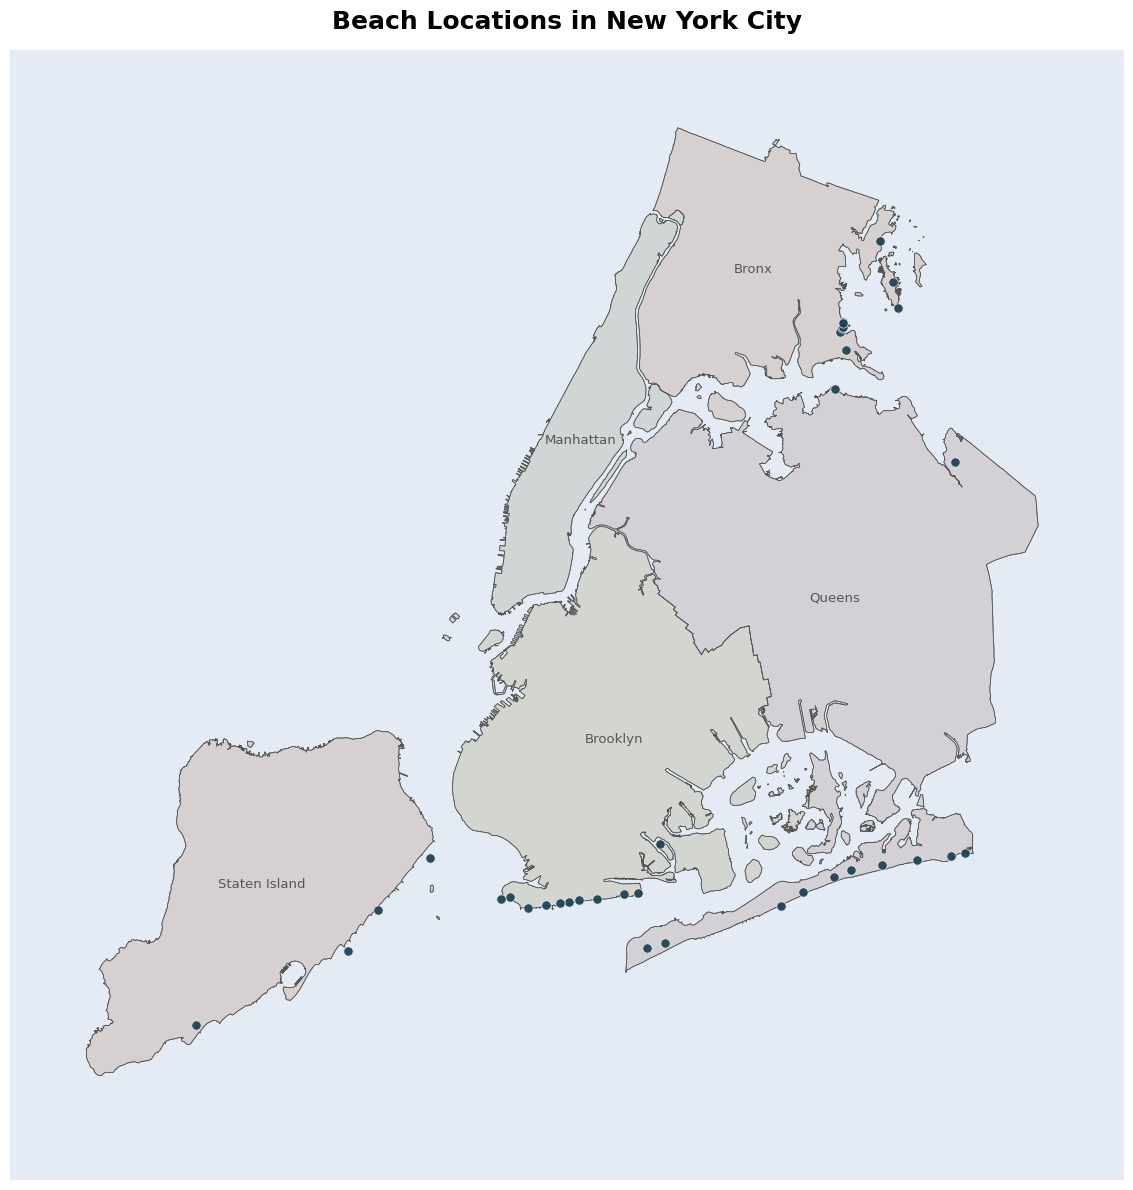

In [351]:
import geopandas as gpd
from shapely.geometry import box



url = "https://raw.githubusercontent.com/Lfab33/Python_Class/refs/heads/main/CSV/beach_dfV2.csv"

df = pd.read_csv(url)

# Create GeoDataFrame
beaches = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["Longitude"],
        df["Latitude"]
    ),
    crs="EPSG:4326"
)

# Keep one point per beach
beaches = beaches.drop_duplicates(
    subset=["Beach Name", "Latitude", "Longitude"]
).copy()




nyc_url = "https://data.cityofnewyork.us/resource/gthc-hcne.geojson"

nyc = gpd.read_file(nyc_url)

# Make sure everything uses the same CRS
nyc = nyc.to_crs("EPSG:4326")

xmin, xmax = -74.30, -73.65
ymin, ymax = 40.45, 40.95



water = gpd.GeoDataFrame(
    geometry=[
        box(xmin, ymin, xmax, ymax)
    ],
    crs="EPSG:4326"
)

borough_colors = {
    "Bronx": "#D6D0D0",
    "Brooklyn": "#d3d6d0",
    "Manhattan": "#d0d5d6",
    "Queens": "#d3d0d6",
    "Staten Island": "#d6d0d2"
}

nyc["borough_color"] = nyc["boroname"].map(borough_colors)



fig, ax = plt.subplots(figsize=(12, 12))

# Water
water.plot(
    ax=ax,
    color ='#e4ebf5',
    #color="#bde0f2",
    edgecolor="none",
    zorder=0
)

# Borough polygons
nyc.plot(
    ax=ax,
    color=nyc["borough_color"],
    edgecolor="#555555",
    linewidth=0.5,
    zorder=1
)

# Borough boundaries
nyc.boundary.plot(
    ax=ax,
    color="#555555",
    linewidth=0.5,
    zorder=2
)

for _, row in nyc.iterrows():
    centroid = row.geometry.centroid

    ax.annotate(
        row["boroname"],
        xy=(centroid.x, centroid.y),
        ha="center",
        va="center",
        fontsize=9.5,
        fontweight="regular",
        fontfamily="sans-serif",
        color="#555555",
        zorder=3
    )

# Beach locations
beaches.plot(
    ax=ax,
    color = '#204352',
    #color="#2c4d6e",
    edgecolor="#e9f2f7",
    linewidth=0.5,
    markersize=45,
    alpha=0.95,
    zorder=3
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)



ax.set_title(
    "Beach Locations in New York City",
    fontsize=18,
    fontweight="bold",
    fontfamily="sans-serif",
    pad=15
)

ax.set_axis_off()

plt.tight_layout()

plt.show()


# Vertical bar chart, beaches by borough, total observations by borough

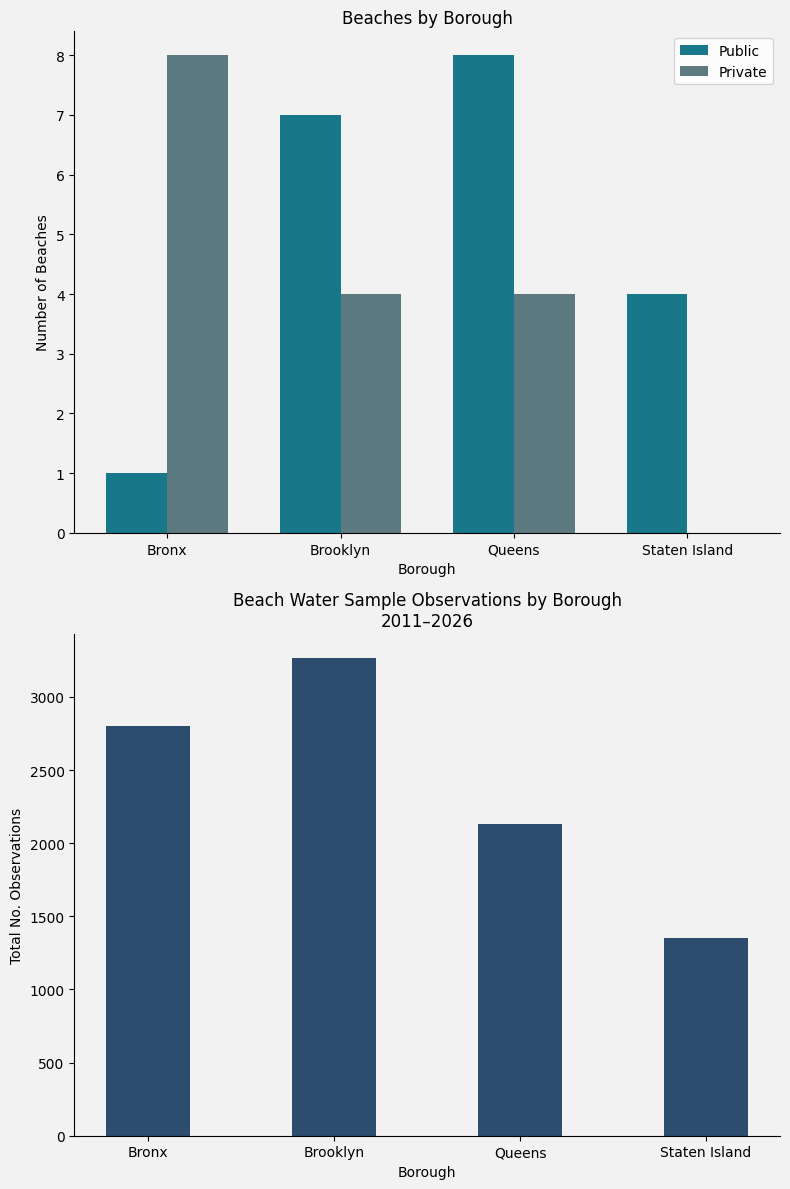

In [352]:
# Unique beaches by Borough and Public/Private
beach_counts = (
    df3.groupby(['Borough', 'Public_Private'])['Beach Name']
    .nunique()
    .unstack(fill_value=0)
)

# Total samples by Borough
sample_counts = df3.groupby('Borough')['Ent SampleAvg'].count()



fig, axes = plt.subplots(2, 1, figsize=(8, 12))




x = np.arange(len(beach_counts.index))
bar_width = 0.30
gap = 0.02



axes[0].bar(
    x - width/2,
    beach_counts['public'],
    width,
    label='Public',
    color='#19778a'
)

axes[0].bar(
    x + width/2,
    beach_counts['private'],
    width,
    label='Private',
    color='#5c7a80'
)

axes[0].set_xlabel('Borough')
axes[0].set_ylabel('Number of Beaches')
axes[0].set_title('Beaches by Borough')
axes[0].set_xticks(x)
axes[0].set_xticklabels(beach_counts.index)
axes[0].legend()

axes[0].set_facecolor('#F2F2F2')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)



axes[1].bar(
    sample_counts.index,
    sample_counts.values,
    color='#2c4d6e',
    width=0.45,

)

axes[1].set_xlabel('Borough')
axes[1].set_ylabel('Total No. Observations')
axes[1].set_title('Beach Water Sample Observations by Borough\n2011–2026')

axes[1].set_facecolor('#F2F2F2')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)



fig.patch.set_facecolor('#F2F2F2')

plt.tight_layout()
plt.show()


# BUILD A HEAT MAP SHOWING THRESHOLD DAYS BY BEACH, BOROUGH AND YEAR, EXPRESSED AS PERCENTAGE TO NORMALIZE

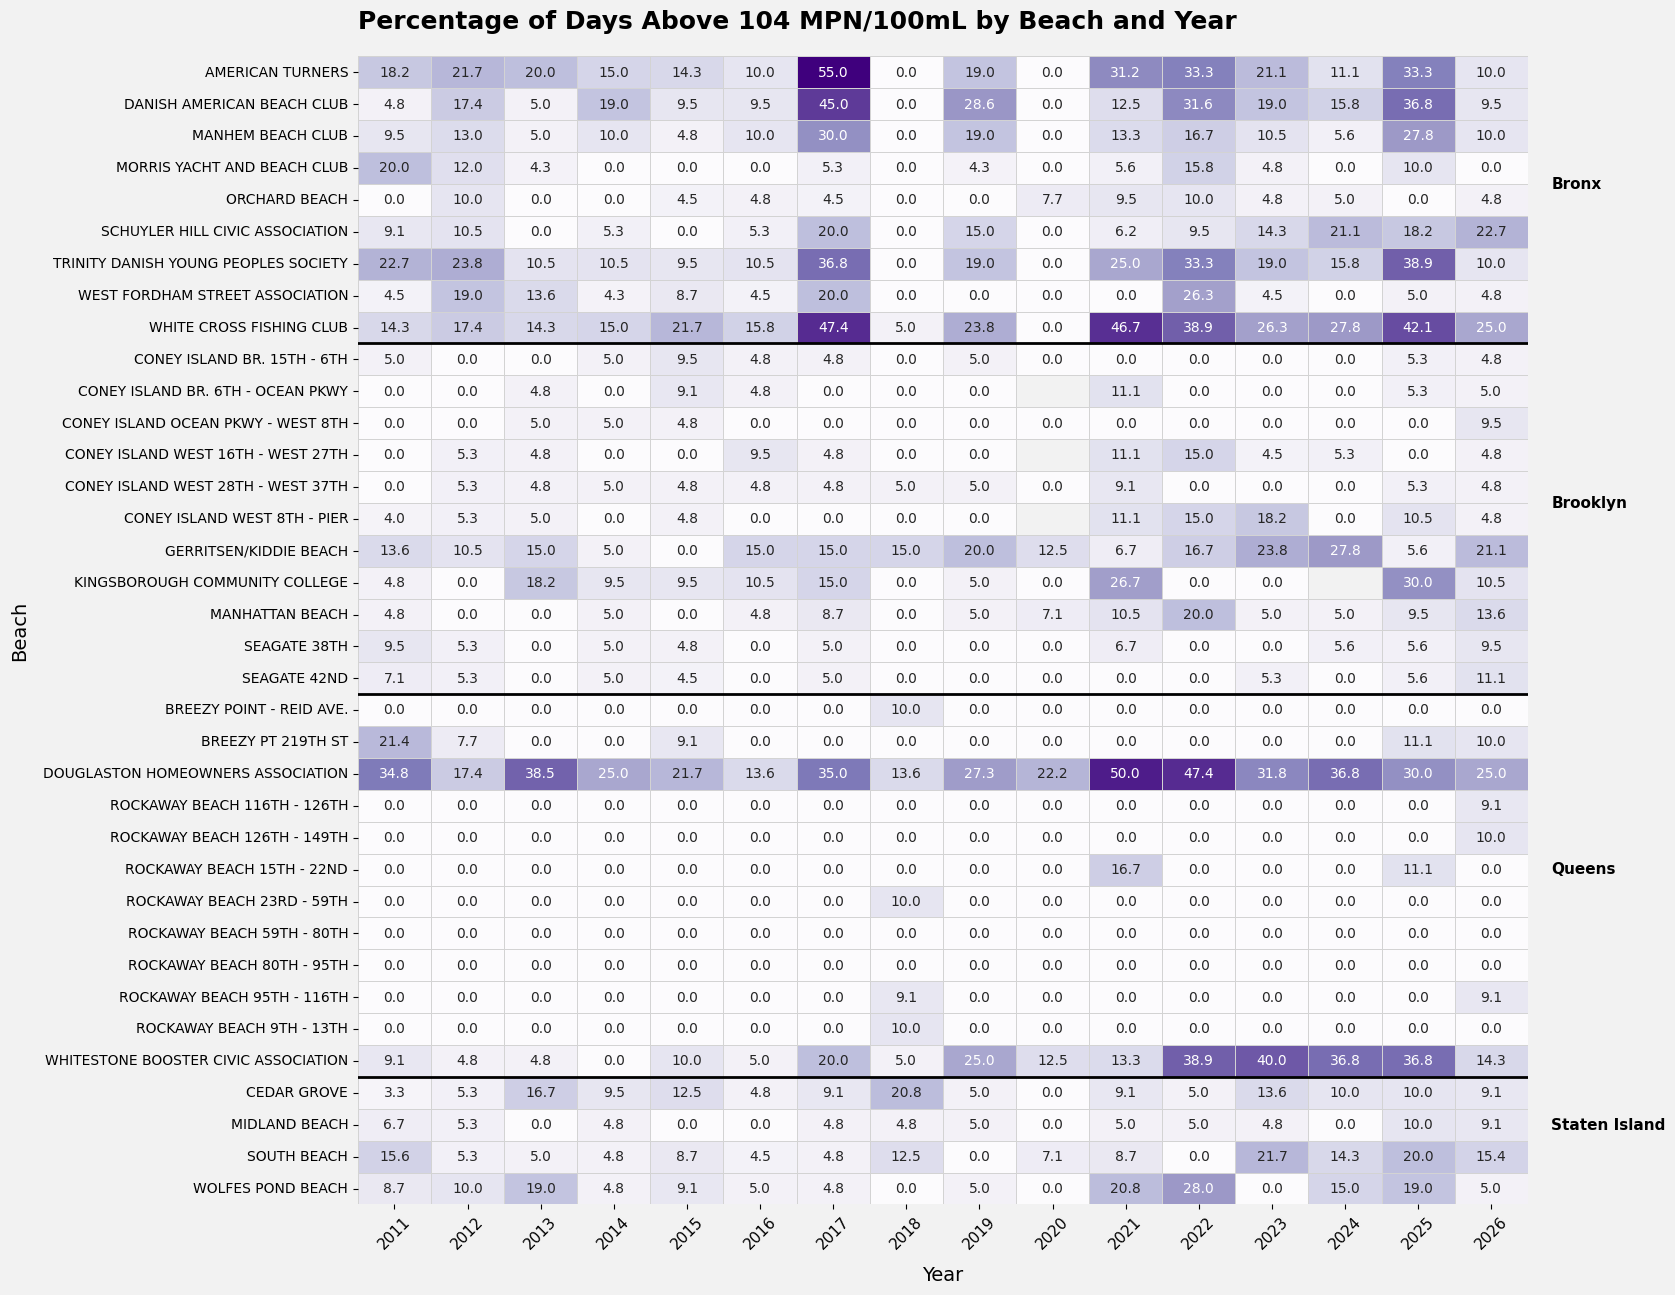

In [353]:
#heatmap by beach, borough and year, expressed as percentage to normalize


beach_year_104 = (
    df3
    .groupby([
        'Year',
        'Borough',
        'Beach Name'
    ])
    .agg(
        Total_Observations=('Ent SampleAvg', 'count'),
        Above_104=('Ent SampleAvg', lambda x: (x > 104).sum())
    )
    .reset_index()
)


beach_year_104['Percent Above 104'] = (
    beach_year_104['Above_104']
    / beach_year_104['Total_Observations']
    * 100
)


heatmap_data = (
    beach_year_104
    .pivot_table(
        index=['Borough', 'Beach Name'],
        columns='Year',
        values='Percent Above 104'
    )
)


heatmap_data = heatmap_data.sort_index(
    level=['Borough', 'Beach Name']
)


boroughs = heatmap_data.index.get_level_values('Borough')
beaches = heatmap_data.index.get_level_values('Beach Name')


fig, ax = plt.subplots(
    figsize=(18, 14)
)

background_color = '#F2F2F2'

fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)


sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='Purples',
    linewidths=0.5,
    linecolor='lightgray',
    cbar=False,
    cbar_kws={
        'label': '% of Sampled Days Above 104 MPN/100mL'
    },
    ax=ax
)

ax.set_yticklabels(
    beaches,
    rotation=0,
    fontsize=10
)


for i in range(1, len(boroughs)):

    if boroughs[i] != boroughs[i - 1]:

        ax.axhline(
            i,
            color='black',
            linewidth=2
        )

borough_groups = []

start = 0

for i in range(1, len(boroughs) + 1):

    if (
        i == len(boroughs)
        or boroughs[i] != boroughs[start]
    ):

        borough = boroughs[start]

        center = (start + i - 1) / 2

        borough_groups.append(
            (borough, center)
        )

        start = i


for borough, center in borough_groups:

    ax.text(
        1.02,
        center,
        borough,
        transform=ax.get_yaxis_transform(),
        ha='left',
        va='center',
        fontsize=11,
        fontweight='bold'
    )


ax.set_title(
    'Percentage of Days Above 104 MPN/100mL by Beach and Year',
    fontsize=18,
    fontweight='bold',
    loc='left',
    pad=20
)

ax.set_xlabel(
    'Year',
    fontsize=14,
    labelpad=10
)

ax.set_ylabel(
    'Beach',
    fontsize=14,
    labelpad=10
)

ax.tick_params(
    axis='x',
    rotation=45,
    labelsize=11
)


plt.subplots_adjust(
    right=0.85,
    left=0.20,
    top=0.92,
    bottom=0.10
)


plt.show()


#Exceedance analysis over time

In [354]:
borough_summary = (
    df3
    .groupby('Borough')
    .agg(
        Total_Observations=('Ent SampleAvg', 'count'),
        Number_of_Exceedances=('Ent SampleAvg', lambda x: (x > 100).sum())
    )
    .reset_index()
)

borough_summary['Percent_Exceedance'] = (
    borough_summary['Number_of_Exceedances']
    / borough_summary['Total_Observations']
    * 100
)

borough_summary = borough_summary.sort_values(
    'Borough',
    ascending=False
)

borough_summary


,Borough,Total_Observations,Number_of_Exceedances,Percent_Exceedance
3,Staten Island,1352,119,8.801775
2,Queens,2132,172,8.067542
1,Brooklyn,3265,172,5.267994
0,Bronx,2802,376,13.418986


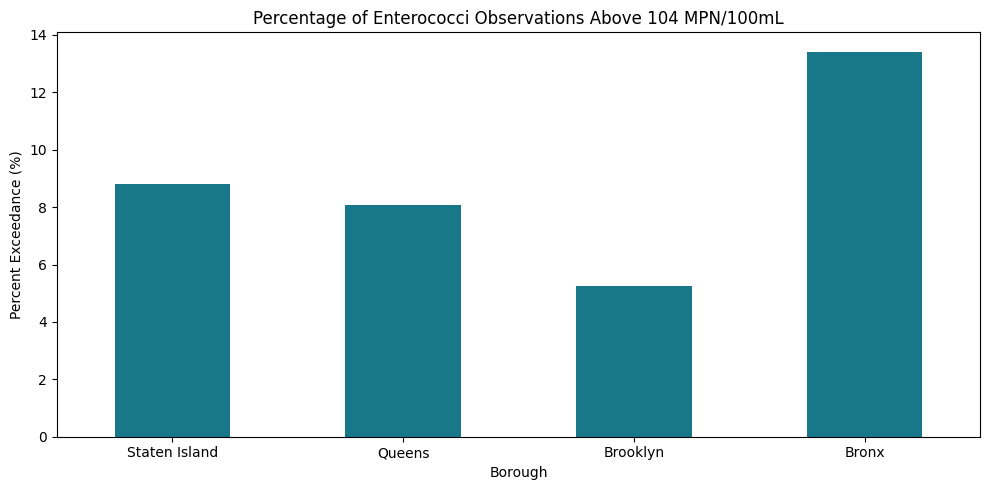

In [355]:
#pct observations (normalized) bar chart of observations

import matplotlib.pyplot as plt

borough_summary.sort_values('Borough', ascending=False).plot(
    x='Borough',
    y='Percent_Exceedance',
    kind='bar',
    color='#19778a',
    legend=False,
    figsize=(10, 5)
)

plt.ylabel('Percent Exceedance (%)')
plt.xlabel('Borough')
plt.title('Percentage of Enterococci Observations Above 104 MPN/100mL')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


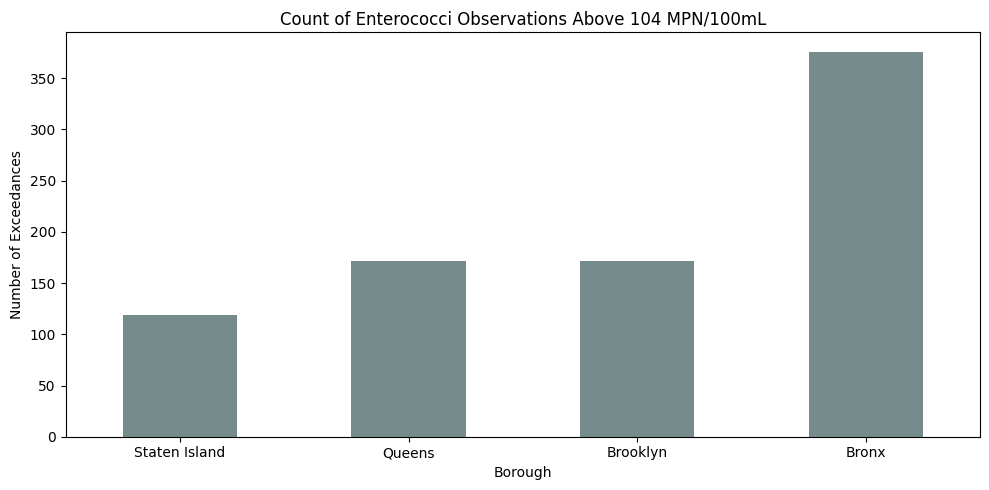

In [356]:
# count of observations by borough bar chart
borough_summary.sort_values('Borough', ascending=False).plot(
    x='Borough',
    y='Number_of_Exceedances',
    kind='bar',
    color='#768c8c',
    legend=False,
    figsize=(10, 5)
)

plt.ylabel('Number of Exceedances')
plt.xlabel('Borough')
plt.title('Count of Enterococci Observations Above 104 MPN/100mL')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [357]:
#exceedance by beach and borogh
beach_summary = (
    df3
    .groupby(['Beach Name', 'Borough'])
    .agg(
        Total_Observations=('Ent SampleAvg', 'count'),
        Number_of_Exceedances=('Ent SampleAvg', lambda x: (x > 100).sum())
    )
    .reset_index()
)

beach_summary['Percent_Exceedance'] = (
    beach_summary['Number_of_Exceedances']
    / beach_summary['Total_Observations']
    * 100
)

beach_summary.sort_values(
    'Number_of_Exceedances',
    ascending=False
)


,Beach Name,Borough,Total_Observations,Number_of_Exceedances,Percent_Exceedance
11,DOUGLASTON HOMEOWNERS ASSOCIATION,Queens,330,102,30.909091
33,WHITE CROSS FISHING CLUB,Bronx,304,77,25.328947
0,AMERICAN TURNERS,Bronx,305,61,20.000000
31,TRINITY DANISH YOUNG PEOPLES SOCIETY,Bronx,301,59,19.601329
34,WHITESTONE BOOSTER CIVIC ASSOCIATION,Queens,304,54,17.763158
10,DANISH AMERICAN BEACH CLUB,Bronx,312,53,16.987179
12,GERRITSEN/KIDDIE BEACH,Brooklyn,299,43,14.381271
15,MANHEM BEACH CLUB,Bronx,302,37,12.251656
35,WOLFES POND BEACH,Staten Island,331,36,10.876133
30,SOUTH BEACH,Staten Island,348,35,10.057471


In [358]:
# exceedence by year
year_summary = (
    df3
    .groupby('Year')
    .agg(
        Total_Observations=('Ent SampleAvg', 'count'),
        Number_of_Exceedances=('Ent SampleAvg', lambda x: (x > 100).sum())
    )
    .reset_index()
)

year_summary['Percent_Exceedance'] = (
    year_summary['Number_of_Exceedances']
    / year_summary['Total_Observations']
    * 100
)

year_summary.sort_values(
    'Number_of_Exceedances',
    ascending=False
)


,Year,Total_Observations,Number_of_Exceedances,Percent_Exceedance
11,2022,572,86,15.034965
6,2017,633,84,13.270142
14,2025,581,81,13.941480
12,2023,617,63,10.210697
15,2026,642,63,9.813084
10,2021,467,58,12.419700
0,2011,712,57,8.005618
1,2012,631,54,8.557845
13,2024,575,51,8.869565
8,2019,639,51,7.981221


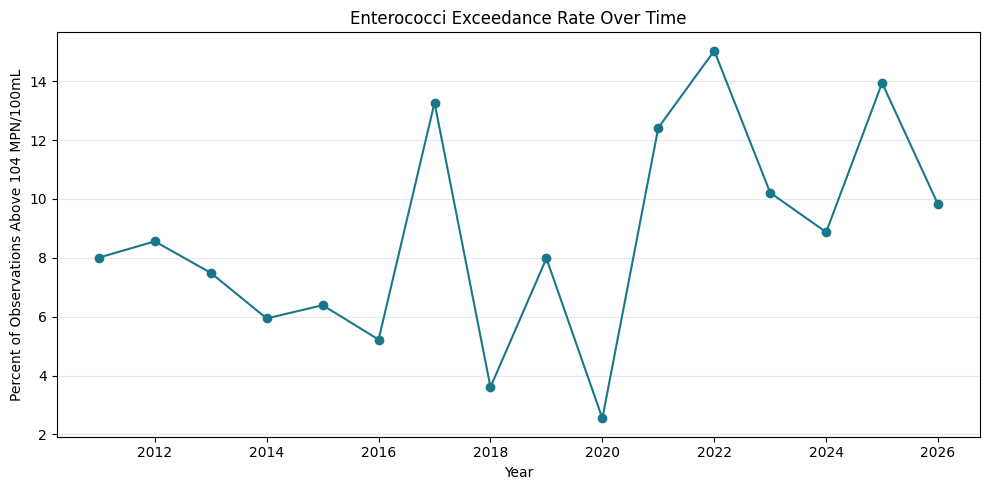

In [359]:


plt.figure(figsize=(10, 5))

plt.plot(
    year_summary['Year'],
    year_summary['Percent_Exceedance'],
    marker='o',
    color='#19778a'
)

plt.xlabel('Year')
plt.ylabel('Percent of Observations Above 104 MPN/100mL')
plt.title('Enterococci Exceedance Rate Over Time')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# 2026 Comparisons

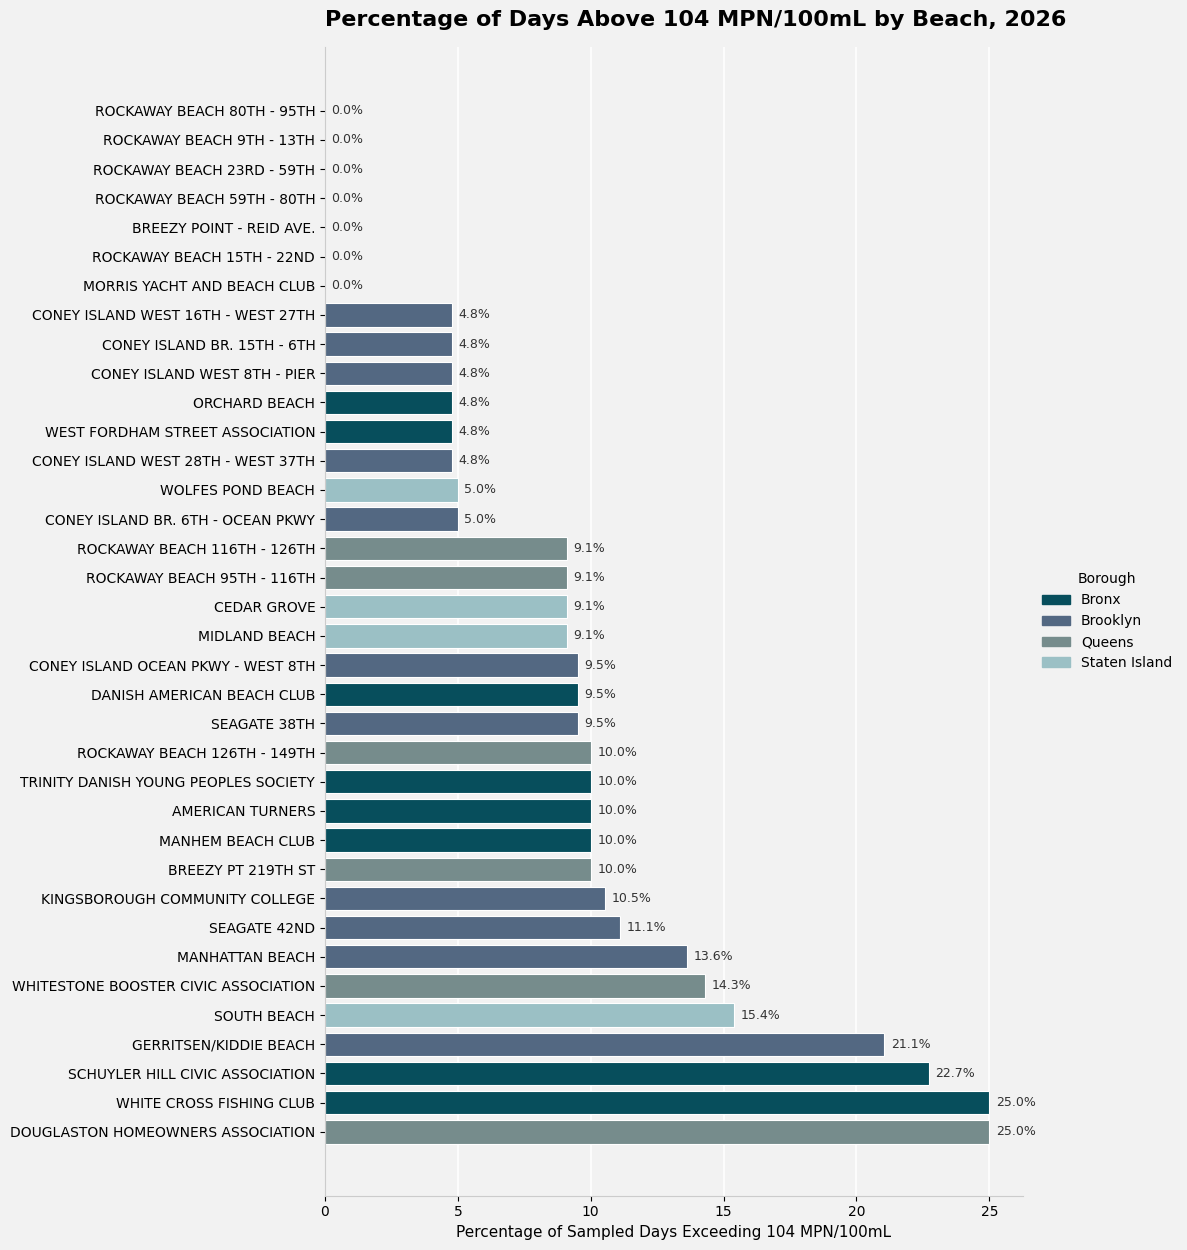

In [360]:
#@title 2026 snapshot
# 2026 snapshot

import matplotlib.pyplot as plt

df3_2026 = df3[
    df3['Year'] == 2026
].copy()

normalized_days = (
    df3_2026
    .groupby(
        [
            'Year',
            'Borough',
            'Beach Name',
            'Latitude',
            'Longitude',
            'Public_Private'
        ]
    )
    .size()
    .reset_index(name='Total Sample Days')
)


closure_thresh = (
    df3_2026[
        df3_2026['Ent SampleAvg'] > 104
    ]
    .groupby(
        [
            'Year',
            'Borough',
            'Beach Name',
            'Latitude',
            'Longitude',
            'Public_Private'
        ]
    )
    .size()
    .reset_index(name='Beach Close Threshold')
)

beach_totals = (
    normalized_days
    .merge(
        closure_thresh,
        on=[
            'Year',
            'Borough',
            'Beach Name',
            'Latitude',
            'Longitude',
            'Public_Private'
        ],
        how='left'
    )
)

beach_totals['Beach Close Threshold'] = (
    beach_totals['Beach Close Threshold']
    .fillna(0)
    .astype(int)
)


beach_totals['Percent Above Threshold'] = (
    beach_totals['Beach Close Threshold']
    / beach_totals['Total Sample Days']
    * 100
)


beach_totals = beach_totals.sort_values(
    'Percent Above Threshold',
    ascending=False
)


borough_colors = {
    'Bronx': '#074e5c',
    'Brooklyn': '#536882',
    'Queens': '#768c8c',
    'Staten Island': '#9BC0C5'
}

colors = [
    borough_colors.get(borough, '#999999')
    for borough in beach_totals['Borough']
]

background_color = '#F2F2F2'


fig, ax = plt.subplots(
    figsize=(12, max(7, len(beach_totals) * 0.35))
)

fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)


ax.barh(
    beach_totals['Beach Name'],
    beach_totals['Percent Above Threshold'],
    color=colors,
    edgecolor='white',
    linewidth=0.8
)


max_value = beach_totals['Percent Above Threshold'].max()

for i, value in enumerate(
    beach_totals['Percent Above Threshold']
):
    ax.text(
        value + max_value * 0.01,
        i,
        f'{value:.1f}%',
        va='center',
        fontsize=9,
        color='#333333'
    )

ax.set_title(
    'Percentage of Days Above 104 MPN/100mL by Beach, 2026',
    fontsize=16,
    fontweight='bold',
    loc='left',
    pad=15
)


ax.set_xlabel(
    'Percentage of Sampled Days Exceeding 104 MPN/100mL',
    fontsize=11
)

ax.set_ylabel('')


ax.grid(
    axis='x',
    color='white',
    linewidth=1.2
)

ax.set_axisbelow(True)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')


legend_handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=color
    )
    for color in borough_colors.values()
]

ax.legend(
    handles=legend_handles,
    labels=borough_colors.keys(),
    title='Borough',
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    frameon=False
)


plt.tight_layout()

plt.show()
